# Superstore Sales Analysis 2014–2017

## Overview
Analysis of 9,994 retail orders across four years and four regions 
to identify revenue trends, profitability drivers, and actionable 
business recommendations.

## Tools Used
- Python (pandas, matplotlib)
- Jupyter Notebook via Kaggle
- Dataset: Sample Superstore (Kaggle)

## Business Questions
1. How does revenue grow year over year?
2. Which region generates most revenue and profit?
3. Which category and sub-category is most profitable?
4. Does discounting increase or destroy profit?
5. Which sub-categories lose money despite high sales?

## Key Findings
- Revenue grew 51.4% from 2014 to 2017 but average order value declined
- Central region underperforms at 7.9% margin due to 24% average discount
- Furniture generates 32.3% revenue but only 2.5% profit margin
- Discounts above 30% collectively lost $135,375
- Tables sells below cost at 108.6% cost ratio in 3 of 4 regions

## Skills Demonstrated
- Exploratory data analysis
- Date format detection and cleaning
- Cost and profitability analysis
- Hypothesis testing
- Data visualisation with matplotlib
- Business insight generation

## About
This project combines Python data analytics with business analysis 
thinking to extract actionable insights from retail sales data.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/naveenkumar20bps1137/sample-superstore/Sample_ Superstore.csv


Read file and convert appropriate dtype after seeing summary of data.

In [2]:
path = (os.path.join(dirname, filename))
sales = pd.read_csv(path, dtype=({"Row ID":"int16","Ship Mode":"category","Segment":"category","Country":"category","City":"category","State":"category","Region":"category","Category":"category","Sub-Category":"category","Quantity":"int8", "Sales":"float64", "Discount":"float64", "Profit":"float64"}), parse_dates = ['Order Date','Ship Date'], dayfirst = False)
#sales = pd.read_csv(path, dtype=({"Row ID":"int16","Ship Mode":"category","Segment":"category","Country":"category","City":"category","State":"category","Region":"category","Category":"category","Sub-Category":"category","Quantity":"int8", "Sales":"float32", "Discount":"float16", "Profit":"float32"}), parse_dates = ['Order Date','Ship Date'], dayfirst = False).dtypes - immediately shows dtype

In [3]:
sales.describe(include='all').round()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.0,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994.0,9994.0,9994.0,9994.0
unique,NaN,5009,1237,1334,4,793,3,1,531,49,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,09-05-2016,12/16/2015,Standard Class,WB-21850,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,5191,9994,915,2001,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,230.0,4.0,0.0,29.0
std,2885.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,623.0,2.0,0.0,234.0
min,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,-6600.0
25%,2499.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0,2.0,0.0,2.0
50%,4998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.0,3.0,0.0,9.0
75%,7496.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210.0,5.0,0.0,29.0


In [4]:
print(sales.shape)
print(sales.columns.tolist())
print(sales.dtypes)
print(sales.isnull().sum())
print(sales.info())

(9994, 19)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID             int16
Order ID          object
Order Date        object
Ship Date         object
Ship Mode       category
Customer ID       object
Segment         category
Country         category
City            category
State           category
Region          category
Product ID        object
Category        category
Sub-Category    category
Product Name      object
Sales            float64
Quantity            int8
Discount         float64
Profit           float64
dtype: object
Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sa

Convert dtype for datetime columns.
First need to run this to check unique formats by sampling.

In [5]:
date_cols = ['Order Date', 'Ship Date']

for col in date_cols:
    print(f"\n{col}")
    print("-" * 30)
    print("Sample values: ")
    print(sales[col].head(10).tolist())
    has_dash = sales[col].str.contains('-').sum()
    has_slash = sales[col].str.contains('/').sum()
    print(f"\nDash format (-): {has_dash:,} rows")
    print(f"Slash format (/): {has_slash:,} rows")
    if has_dash > 0 and has_slash > 0 :
        print(" MIXED FORMATS DETECTED")
    elif has_dash > 0:
        print("Single format - dashes only")
    elif has_slash > 0:
        print("Single format - slashes only")


Order Date
------------------------------
Sample values: 
['11-08-2016', '11-08-2016', '06-12-2016', '10-11-2015', '10-11-2015', '06-09-2014', '06-09-2014', '06-09-2014', '06-09-2014', '06-09-2014']

Dash format (-): 4,042 rows
Slash format (/): 5,952 rows
 MIXED FORMATS DETECTED

Ship Date
------------------------------
Sample values: 
['11-11-2016', '11-11-2016', '6/16/2016', '10/18/2015', '10/18/2015', '6/14/2014', '6/14/2014', '6/14/2014', '6/14/2014', '6/14/2014']

Dash format (-): 3,898 rows
Slash format (/): 6,096 rows
 MIXED FORMATS DETECTED


Apply Multi-Format Parser

In [6]:
def parse_mixed_dates(date_str):#takes one arg date_str
    for fmt in ('%m-%d-%Y','%m/%d/%Y'):#loops through 2 possible date formats
        try: 
            return pd.to_datetime(date_str, format=fmt)#try convert date_str using current fmt
        except:
            continue
    return pd.NaT

sales['Order Date'] = sales['Order Date'].apply(parse_mixed_dates)
sales['Ship Date'] = sales['Ship Date'].apply(parse_mixed_dates)


print(f"Order Date nulls: {sales['Order Date'].isna().sum()}")
print(f"Ship Date nulls: {sales['Ship Date'].isna().sum()}")


Order Date nulls: 0
Ship Date nulls: 0


In [7]:
sales['Order Date']=pd.to_datetime(sales['Order Date'],
                                  errors= "coerce",
                                  infer_datetime_format = True)

sales['Ship Date'] = pd.to_datetime(sales['Ship Date'],
                                   errors='coerce')

/tmp/ipykernel_16/515080776.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  sales['Order Date']=pd.to_datetime(sales['Order Date'],


In [8]:
print(sales[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


Viewing random sample to see the overall data.

In [9]:
sales.sample(20, random_state=12345)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6627,6628,CA-2014-138513,2014-05-23,2014-05-27,Standard Class,EH-13990,Consumer,United States,Bellevue,Washington,West,OFF-PA-10003177,Office Supplies,Paper,Xerox 1999,12.960,2,0.0,6.2208
2698,2699,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Home Office,United States,Jacksonville,Florida,South,OFF-PA-10001804,Office Supplies,Paper,Xerox 195,21.376,4,0.2,7.4816
7512,7513,US-2017-161935,2017-07-14,2017-07-18,Standard Class,JL-15835,Consumer,United States,Columbus,Ohio,East,OFF-ST-10001837,Office Supplies,Storage,"SAFCO Mobile Desk Side File, Wire Frame",239.456,7,0.2,17.9592
5000,5001,CA-2017-159688,2017-05-07,2017-05-12,Standard Class,AB-10060,Home Office,United States,Los Angeles,California,West,TEC-AC-10000736,Technology,Accessories,Logitech G600 MMO Gaming Mouse,79.990,1,0.0,28.7964
4622,4623,CA-2017-147228,2017-09-09,2017-09-14,Standard Class,SO-20335,Consumer,United States,Columbia,Tennessee,South,OFF-SU-10001225,Office Supplies,Supplies,Staple remover,8.832,3,0.2,-1.9872
6856,6857,US-2017-162670,2017-12-23,2017-12-28,Second Class,MF-18250,Corporate,United States,Little Rock,Arkansas,South,OFF-EN-10001453,Office Supplies,Envelopes,"Tyvek Interoffice Envelopes, 9 1/2"" x 12 1/2"",...",182.940,3,0.0,85.9818
2907,2908,CA-2017-121615,2017-11-03,2017-11-09,Standard Class,DL-12925,Consumer,United States,Eagan,Minnesota,Central,OFF-ST-10001325,Office Supplies,Storage,Sterilite Officeware Hinged File Box,52.400,5,0.0,14.1480
6537,6538,CA-2014-169684,2014-10-20,2014-10-23,First Class,FH-14365,Corporate,United States,Knoxville,Tennessee,South,OFF-ST-10000934,Office Supplies,Storage,"Contico 72""H Heavy-Duty Storage System",98.352,3,0.2,-24.5880
9247,9248,CA-2017-130106,2017-05-22,2017-05-26,Standard Class,VF-21715,Home Office,United States,San Francisco,California,West,OFF-AR-10003732,Office Supplies,Art,Newell 333,2.780,1,0.0,0.7228
9219,9220,US-2015-164238,2015-08-16,2015-08-20,Standard Class,JW-15955,Consumer,United States,Philadelphia,Pennsylvania,East,FUR-BO-10000780,Furniture,Bookcases,O'Sullivan Plantations 2-Door Library in Landv...,301.470,3,0.5,-204.9996


Convert Order Date to see when order is places and sales trends (seasonality, peak periods) and add additional date columns (Year, Quarter, Day of Week).
Then see the overall of the converted data for first analysis.

In [10]:
sales = sales.assign(
    sales_year = sales["Order Date"].dt.year.astype('int16'),
    sales_quarter = sales["Order Date"].dt.quarter.astype('int8'),
    sales_dow = sales["Order Date"].dt.dayofweek.astype('int8'),
)

print(sales[['Order Date', 'sales_year', 'sales_quarter', 'sales_dow']].head(10))
print("Years covered:")
print(sales['sales_year'].value_counts().sort_index())
#print(sales[['Order Date', 'sales_year', 'sales_quarter', 'sales_dow']].describe(include='all').T)
# Convert to date string before describe
temp = sales[['Order Date', 'sales_year', 'sales_quarter', 'sales_dow']].copy()
temp['Order Date'] = temp['Order Date'].dt.date

print(temp.describe(include='all').T)

  Order Date  sales_year  sales_quarter  sales_dow
0 2016-11-08        2016              4          1
1 2016-11-08        2016              4          1
2 2016-06-12        2016              2          6
3 2015-10-11        2015              4          6
4 2015-10-11        2015              4          6
5 2014-06-09        2014              2          0
6 2014-06-09        2014              2          0
7 2014-06-09        2014              2          0
8 2014-06-09        2014              2          0
9 2014-06-09        2014              2          0
Years covered:
sales_year
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64
                count unique         top freq         mean       std     min  \
Order Date       9994   1237  2016-09-05   38          NaN       NaN     NaN   
sales_year     9994.0    NaN         NaN  NaN  2015.722233  1.123555  2014.0   
sales_quarter  9994.0    NaN         NaN  NaN     2.882329  1.058086     1.0   
sales_dow      

**Questions**
1. How does revenue grow year over year?
2. Which region generates most revenue and profit?
3. Which category and sub-category is most profitable?
4. Does discounting increase or destroy profit?
5. Which sub-categories lose money despite high sales?

**Q1: How does revenue grow year over year?**
**First analysis**

1. 4 years of data - 2014 to 2017
2. Growth trends upwards, 66% increase over 4 years.
3. Order date = 9,994 rows, 1,237 unique dates, common date:2016-09-05
4. Sales year: Mean = 2015 - data weighted towards later years, most orders 2017 with 3,312
5. Sales quarter : Mean is 2.88 - closer to Q3, second half more busy.
6. Sales of day of the week : 50% is on Friday (mean is 3.2), max/many orders on Sunday. 25% or less order on Monday.



**Seeing pattern of orders based on day of week**

In [11]:
dow_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday',
           3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}

dow_counts = sales['sales_dow'].map(dow_map).value_counts()
#convert df with percentage

dow_df = pd.DataFrame({
    'Count' : dow_counts,
    'Percentage': (dow_counts / dow_counts.sum() * 100).round(1)
})
dow_df.index.name = 'Day'
print(dow_df)

           Count  Percentage
Day                         
Monday      1871        18.7
Friday      1818        18.2
Sunday      1710        17.1
Saturday    1655        16.6
Thursday    1463        14.6
Tuesday     1106        11.1
Wednesday    371         3.7


**Second Analysis**
1. Monday is the busiest with 18.7% 
2. Wednesday is very low, 3.7%. Need more data from stakeholders.
3. Weekends are strong, Sat and Sun with 16.6% and 17.1% respectively.


In [12]:
yearly_sales = sales.groupby('sales_year')['Sales'].sum().reset_index() #for each unique sales_year, sum the sales
yearly_sales.columns = ['Year','Total Sales']
yearly_sales['Growth %'] = yearly_sales['Total Sales'].pct_change() * 100
yearly_sales['Growth %'] = yearly_sales['Growth %'].round(1)
yearly_sales['Total Sales'] = yearly_sales['Total Sales'].astype('float64').round(2)
print(yearly_sales)


   Year  Total Sales  Growth %
0  2014    484247.50       NaN
1  2015    470532.51      -2.8
2  2016    609205.60      29.5
3  2017    733215.26      20.4


**Third Analysis**

1. Total growth 2014 to 2017 is 51.4%
2. The deep on 2015 is interesting.


**Build the chart**

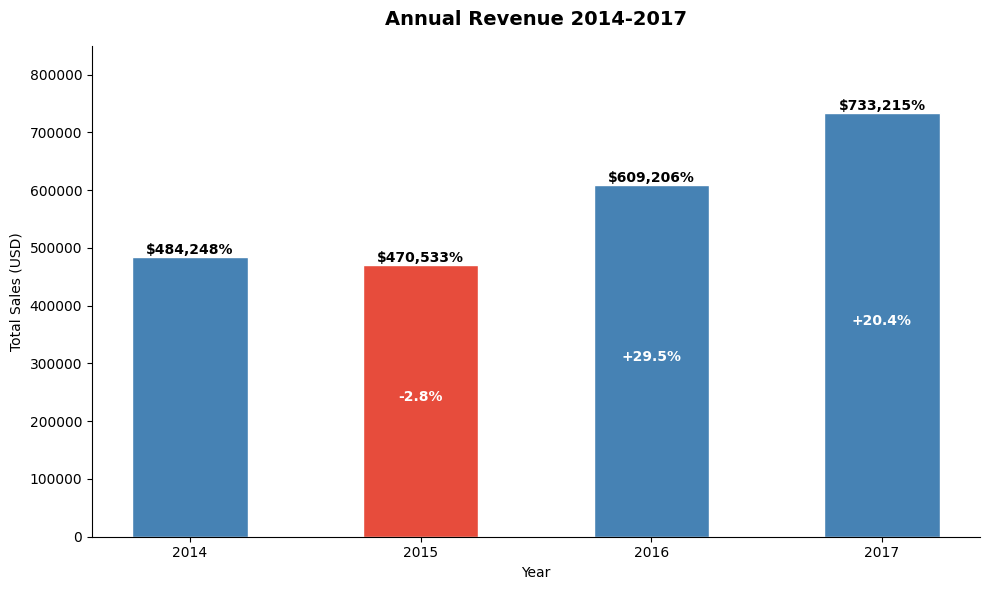

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))  
#blank canvas, fig whole figure, ax plot area, width 10', height 6'
colors = ['#e74c3c' if g<0 else 'steelblue'
         for g in yearly_sales['Growth %'].fillna(0)]
#builds a list of 4 colors, if g growth negative gets red, else blue. fillna(0) for NaN to avoid crash

bars = ax.bar(yearly_sales['Year'].astype(str), #ax.bar is vertical bar, convert year to sales so not in 2,014 format
             yearly_sales['Total Sales'], #height
             color = colors,
             edgecolor = 'white',
             width=0.5) #spacing

#add value labels
for bar, (_, row) in zip(bars, yearly_sales.iterrows()): #for every bar, index, row data
    #sales amount on top of bar
    ax.text(bar.get_x() + bar.get_width()/2, #place text on chart at the edge of bar and move right by half bar width
           bar.get_height() + 5000, #vertical position of amount
           f"${row['Total Sales']:,.0f}%",
           ha='center', fontsize=10, fontweight='bold')
    #Growth % inside bar
    if not pd.isna(row['Growth %']): #check if growth is NAN
        ax.text(bar.get_x() + bar.get_width()/2, #place growth% inside the bar
               bar.get_height()/2, #position at half of the bar
               f"{row['Growth %']:+.1f}%",
               ha='center', fontsize=10,
               color='white', fontweight='bold')

ax.set_title('Annual Revenue 2014-2017',
            fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel('Year')
ax.set_ylabel('Total Sales (USD)')
ax.set_ylim(0, 850000) #y-axis range
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout() #nothing cut off
#plt.savefig('chart1_yearly_revenue.png', dpi=150)
plt.show()

**Q2: Which region generates most revenue and profit**

Start with region first for executive overview, focus on state to spot strong and weak sales.

In [14]:
region_sales = sales.groupby('Region').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Order_Count = ('Sales', 'count')
).reset_index()

region_sales['Total_Sales'] = region_sales['Total_Sales'].astype('float64').round(2)
region_sales['Total_Profit'] = region_sales['Total_Profit'].astype('float64').round(2)
region_sales['Sales %'] = (region_sales['Total_Sales']/ region_sales['Total_Sales'].sum() * 100).round(1)
region_sales['Profit_Margin'] = (region_sales['Total_Profit'] / region_sales['Total_Sales']*100).round(1)

region_sales = region_sales.sort_values('Total_Sales', ascending=False).reset_index(drop=True) #method calling not accessing item/column

print(region_sales)

    Region  Total_Sales  Total_Profit  Order_Count  Sales %  Profit_Margin
0     West    725457.82     108418.45         3203     31.6           14.9
1     East    678781.24      91522.78         2848     29.5           13.5
2  Central    501239.89      39706.36         2323     21.8            7.9
3    South    391721.90      46749.43         1620     17.1           11.9


/tmp/ipykernel_16/3811446739.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_sales = sales.groupby('Region').agg(


**Fourth Analysis**

* West has the highest total sales and profit.
* South has the lowest total sales and profit but the profit margin is third highest. 
* West generated double the South's revenue.
* Central has the lowest profit margin even placed in third of total sales by region.

**Build the chart**

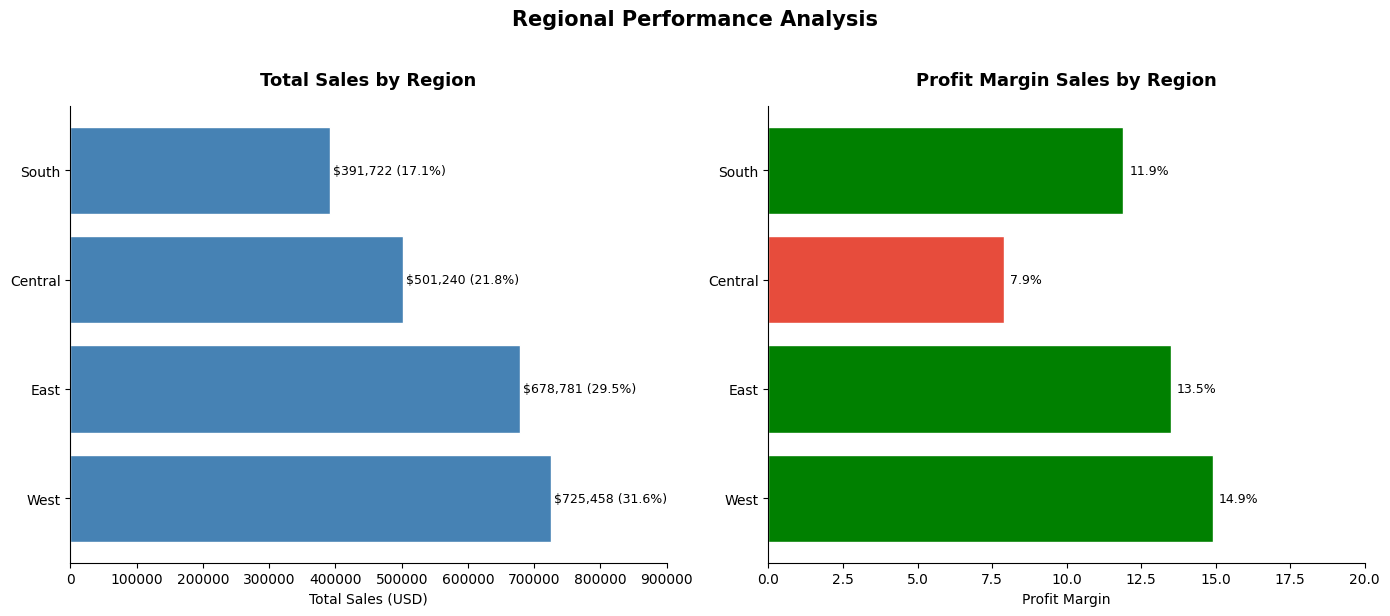

In [15]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14, 6))

#LEFT - Total Sales by Region
bars1 = ax1.barh(region_sales['Region'],
                region_sales['Total_Sales'],
                color='steelblue',
                edgecolor='white')

for bar, (_, row) in zip(bars1, region_sales.iterrows()):
    ax1.text(bar.get_width() + 5000,
            bar.get_y() + bar.get_height()/2,
            f"${row['Total_Sales']:,.0f} ({row['Sales %']}%)",
            va='center', fontsize=9)

ax1.set_title('Total Sales by Region',
             fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Total Sales (USD)')
ax1.set_xlim(0, 900000)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#RIGHT - Profit Margin by Region

colors2 = ['#e74c3c' if m< 10 else 'green'
          for m in region_sales['Profit_Margin']]

bars2 = ax2.barh(region_sales['Region'],
                region_sales['Profit_Margin'],
                color=colors2,
                edgecolor='white')

for bar, (_, row) in zip(bars2, region_sales.iterrows()):
    ax2.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f"{row['Profit_Margin']}%",
            va='center', fontsize=9)

ax2.set_title('Profit Margin Sales by Region',
             fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Profit Margin')
ax2.set_xlim(0, 20)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Regional Performance Analysis',
             fontsize = 15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Analysis based on charts**
* West has the highest sales by region, $725,458
* South has the lowest sales by region, $391,722.3.
* Central has the lowest profit margin sales by region despite being the second lowest total sales.


**Q3. Which category and sub-category is most profitable?**

In [16]:
cat_sales = sales.groupby('Category').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Order_Count = ('Sales', 'count')
).reset_index()

cat_sales['Total_Sales'] = cat_sales['Total_Sales'].astype('float64').round(2)
cat_sales['Total_Profit'] = cat_sales['Total_Profit'].astype('float64').round(2)
cat_sales['Sales %'] = (cat_sales['Total_Sales']/ cat_sales['Total_Sales'].sum() * 100).round(1)
cat_sales['Profit_Margin'] = (cat_sales['Total_Profit'] / cat_sales['Total_Sales']*100).round(1)

cat_sales = cat_sales.sort_values('Total_Profit', ascending=False).reset_index(drop=True) #method calling not accessing item/column

cat_sales

/tmp/ipykernel_16/322990360.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_sales = sales.groupby('Category').agg(


,Category,Total_Sales,Total_Profit,Order_Count,Sales %,Profit_Margin
0,Technology,836154.03,145454.95,1847,36.4,17.4
1,Office Supplies,719047.03,122490.80,6026,31.3,17.0
2,Furniture,741999.80,18451.27,2121,32.3,2.5


**Fifth Analysis**

1. Highest Category is Technology with profit $145,454.95 and margin profit of 17.4%
2. Technology has the lowest orders but generates most profit.
3. Office Supplies has the highest order count.
4. Profit margin for office supplies is strong, 17.0%
5. Lower value per order but consistent volume.
6. Furniture has the second highest sales but profit margin is the lowest, 2.5%. Need to find the reason why? (Discounting or high cost of goods)

In [17]:
#Sub-category

subcat_sales = sales.groupby('Sub-Category').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Order_Count = ('Sales', 'count')
).reset_index()

subcat_sales['Total_Sales'] = subcat_sales['Total_Sales'].astype('float64').round(2)
subcat_sales['Total_Profit'] = subcat_sales['Total_Profit'].astype('float64').round(2)
subcat_sales['Sales %'] = (subcat_sales['Total_Sales']/ subcat_sales['Total_Sales'].sum() * 100).round(1)
subcat_sales['Profit_Margin'] = (subcat_sales['Total_Profit'] / subcat_sales['Total_Sales']*100).round(1)

cat_mapping = sales[['Category', 'Sub-Category']].drop_duplicates()
subcat_sales = subcat_sales.merge(cat_mapping, on='Sub-Category')
subcat_sales = subcat_sales[['Sub-Category', 'Category', 'Total_Sales', 'Total_Profit', 'Order_Count', 'Sales %', 'Profit_Margin']]

subcat_sales = subcat_sales.sort_values('Total_Profit', ascending=False).reset_index(drop=True) #method calling not accessing item/column
subcat_sales


/tmp/ipykernel_16/1587801638.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subcat_sales = sales.groupby('Sub-Category').agg(


,Sub-Category,Category,Total_Sales,Total_Profit,Order_Count,Sales %,Profit_Margin
0,Copiers,Technology,149528.03,55617.82,68,6.5,37.2
1,Phones,Technology,330007.05,44515.73,889,14.4,13.5
2,Accessories,Technology,167380.32,41936.64,775,7.3,25.1
3,Paper,Office Supplies,78479.21,34053.57,1370,3.4,43.4
4,Binders,Office Supplies,203412.73,30221.76,1523,8.9,14.9
5,Chairs,Furniture,328449.10,26590.17,617,14.3,8.1
6,Storage,Office Supplies,223843.61,21278.83,846,9.7,9.5
7,Appliances,Office Supplies,107532.16,18138.01,466,4.7,16.9
8,Furnishings,Furniture,91705.16,13059.14,957,4.0,14.2
9,Envelopes,Office Supplies,16476.40,6964.18,254,0.7,42.3


In [18]:
subcat_sales = subcat_sales.sort_values('Total_Sales', ascending=False).reset_index(drop=True) #method calling not accessing item/column
subcat_sales

,Sub-Category,Category,Total_Sales,Total_Profit,Order_Count,Sales %,Profit_Margin
0,Phones,Technology,330007.05,44515.73,889,14.4,13.5
1,Chairs,Furniture,328449.10,26590.17,617,14.3,8.1
2,Storage,Office Supplies,223843.61,21278.83,846,9.7,9.5
3,Tables,Furniture,206965.53,-17725.48,319,9.0,-8.6
4,Binders,Office Supplies,203412.73,30221.76,1523,8.9,14.9
5,Machines,Technology,189238.63,3384.76,115,8.2,1.8
6,Accessories,Technology,167380.32,41936.64,775,7.3,25.1
7,Copiers,Technology,149528.03,55617.82,68,6.5,37.2
8,Bookcases,Furniture,114880.00,-3472.56,228,5.0,-3.0
9,Appliances,Office Supplies,107532.16,18138.01,466,4.7,16.9


In [19]:
subcat_sales = subcat_sales.sort_values('Profit_Margin', ascending=False).reset_index(drop=True) #method calling not accessing item/column
subcat_sales

,Sub-Category,Category,Total_Sales,Total_Profit,Order_Count,Sales %,Profit_Margin
0,Labels,Office Supplies,12486.31,5546.25,364,0.5,44.4
1,Paper,Office Supplies,78479.21,34053.57,1370,3.4,43.4
2,Envelopes,Office Supplies,16476.40,6964.18,254,0.7,42.3
3,Copiers,Technology,149528.03,55617.82,68,6.5,37.2
4,Fasteners,Office Supplies,3024.28,949.52,217,0.1,31.4
5,Accessories,Technology,167380.32,41936.64,775,7.3,25.1
6,Art,Office Supplies,27118.79,6527.79,796,1.2,24.1
7,Appliances,Office Supplies,107532.16,18138.01,466,4.7,16.9
8,Binders,Office Supplies,203412.73,30221.76,1523,8.9,14.9
9,Furnishings,Furniture,91705.16,13059.14,957,4.0,14.2


**Sixth Analysis**

1. Top 3 highest profit for sub-category are Copiers, Phones & Accessories.
2. Bottom 3 lowest profit are Supplies, Bookcases, Tables.
3. Top 3 highest sales are Phones, Chairs, & Storage.
4. Bottom 3 lowest sales are Envelopes, Labels and Fasteners.
5. Top 3 highest profit margin are Labels, Paper, & Envelopes.
6. Bottom 3 lowest profit margin are Supplies, Bookcases and Tables.
7. Category with lowest profit margin Furnitures.
8. Tables alone loses $17,725 despite revenue of $206,966 revenue; the fourth largest sub-category by sales.

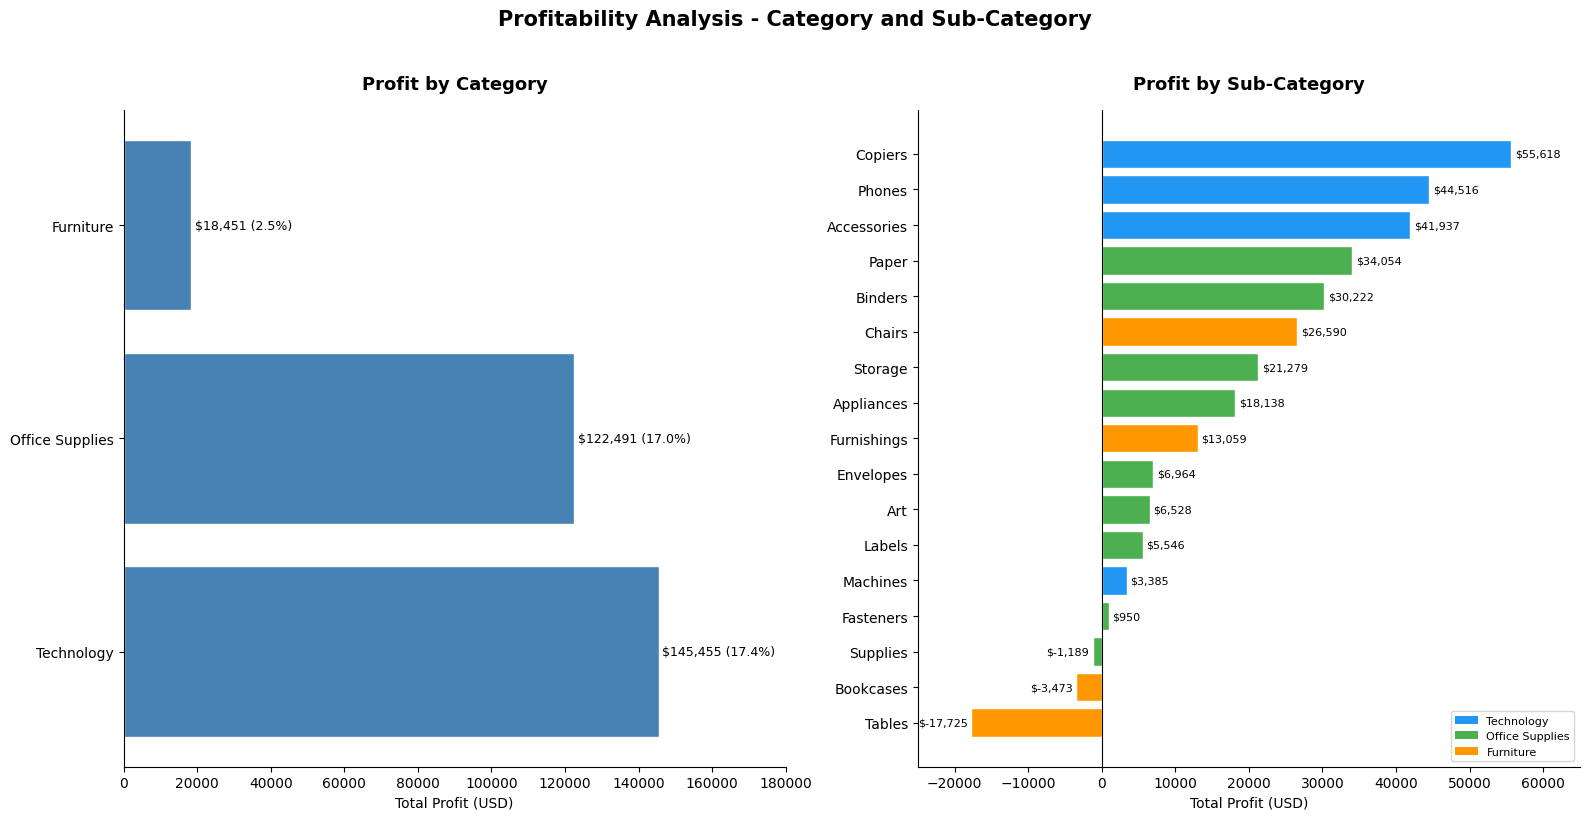

In [20]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

#LEFT - Category Profit

colors_cat = ['#e74c3c' if m< 0 else 'steelblue'
          for m in cat_sales['Total_Profit']]

bars1 = ax1.barh(cat_sales['Category'],
                cat_sales['Total_Profit'],
                color=colors_cat,
                edgecolor='white')

for bar, (_, row) in zip(bars1, cat_sales.iterrows()):
    ax1.text(bar.get_width() + 1000,
            bar.get_y() + bar.get_height()/2,
            f"${row['Total_Profit']:,.0f} ({row['Profit_Margin']}%)",
            va='center', fontsize=9)

ax1.set_title('Profit by Category',
             fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Total Profit (USD)')
ax1.set_xlim(0, 180000)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#RIGHT - SUB-CATEGORY

category_colors = {
    'Technology'     : '#2196F3',
    'Office Supplies': '#4CAF50',
    'Furniture'      : '#FF9800'
}

subcat_sorted = subcat_sales.sort_values('Total_Profit')

colors_sub = [category_colors[cat]
              for cat in subcat_sorted['Category']]

bars2 = ax2.barh(subcat_sorted['Sub-Category'],
                subcat_sorted['Total_Profit'],
                color=colors_sub,
                edgecolor='white')

for bar, (_, row) in zip(bars2, subcat_sorted.iterrows()):
    xpos = bar.get_width() + 500 if bar.get_width() >= 0 else bar.get_width() - 500
    align = 'left' if bar.get_width() >= 0 else 'right'
    ax2.text(xpos,
             bar.get_y() + bar.get_height()/2,
             f"${row['Total_Profit']:,.0f}",
             va='center', fontsize=8, ha=align)

#zero line
ax2.axvline(x=0, color='black', linewidth=0.8)

#legend
from matplotlib.patches import Patch
legend_elements=[
    Patch(facecolor = '#2196F3', label='Technology'),
    Patch(facecolor = '#4CAF50', label='Office Supplies'),
    Patch(facecolor = '#FF9800', label='Furniture'),

]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=8)

ax2.set_title('Profit by Sub-Category',
             fontsize=13, fontweight='bold', pad=15)
ax2.set_xlim(-25000, 65000)
ax2.set_xlabel('Total Profit (USD)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Profitability Analysis - Category and Sub-Category',
             fontsize = 15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Analysis based on charts**
1. Technology has the highest profit by category, $145,455 with 17.4% margin.
2. The highest profit of sub-category is Copier, $55,618.
3. Tables in furniture category is having huge loses of $17,725.
4. Technology leads with the highest sub-category profit.
5. Furniture has two sub-category that facing loses, bookcases and tables.

**Q4 Does discounting increase or destroy profit?**


In [21]:
discount_analysis = sales.groupby('Discount').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Order_Count = ('Sales', 'count')
).reset_index()


discount_analysis['Total_Sales'] = discount_analysis['Total_Sales'].astype('float64').round(2)
discount_analysis['Total_Profit'] = discount_analysis['Total_Profit'].astype('float64').round(2)
discount_analysis['Sales %'] = (discount_analysis['Total_Sales']/ discount_analysis['Total_Sales'].sum() * 100).round(1)
discount_analysis['Profit_Margin'] = (discount_analysis['Total_Profit'] / discount_analysis['Total_Sales']*100).round(1)

discount_analysis


,Discount,Total_Sales,Total_Profit,Order_Count,Sales %,Profit_Margin
0,0.00,1087908.47,320987.60,4798,47.4,29.5
1,0.10,54369.35,9029.18,94,2.4,16.6
2,0.15,27558.52,1418.99,52,1.2,5.1
3,0.20,764594.37,90337.31,3657,33.3,11.8
4,0.30,103226.66,-10369.28,227,4.5,-10.0
5,0.32,14493.46,-2391.14,27,0.6,-16.5
6,0.40,116417.78,-23057.05,206,5.1,-19.8
7,0.45,5484.97,-2493.11,11,0.2,-45.5
8,0.50,58918.54,-20506.43,66,2.6,-34.8
9,0.60,6644.70,-5944.66,138,0.3,-89.5


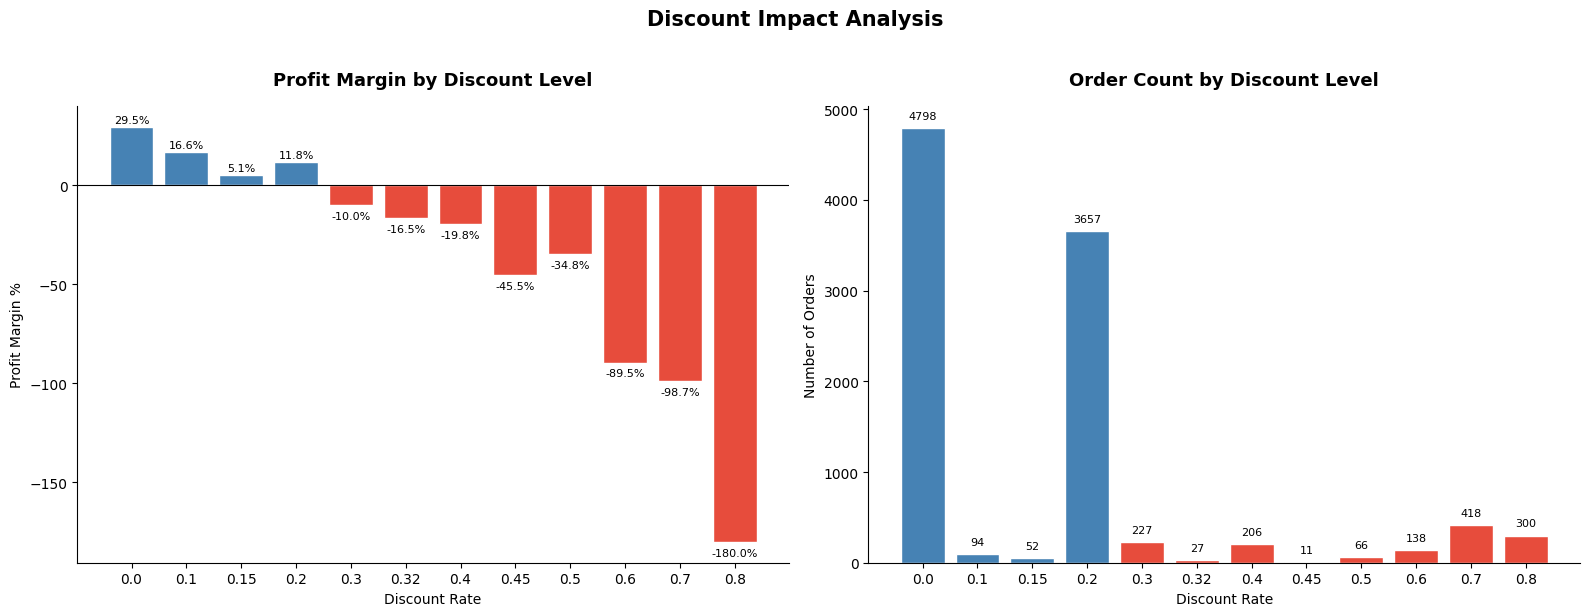

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

#LEFT - Profit Margin by Discount Level
colors_disc = ['#e74c3c' if m < 0 else 'steelblue'
              for m in discount_analysis['Profit_Margin']]

bars1 = ax1.bar(discount_analysis['Discount'].astype(str),
               discount_analysis['Profit_Margin'],
               color=colors_disc,
               edgecolor='white')

for bar,(_, row) in zip(bars1, discount_analysis.iterrows()):
    ypos = bar.get_height() + 1 if bar.get_height() >=0 else bar.get_height() - 8
    align = 'center'
    ax1.text(bar.get_x() + bar.get_width()/2,
            ypos,
            f"{row['Profit_Margin']}%",
            ha=align, va='bottom', fontsize=8)

ax1.axhline(y=0, color='black', linewidth=0.8) #horizontal line
ax1.set_title('Profit Margin by Discount Level',
             fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Discount Rate')
ax1.set_ylabel('Profit Margin %')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#RIGHT - Order Count by Discount Level

colors_count = ['#e74c3c' if d >= 0.3 else 'steelblue'
               for d in discount_analysis['Discount']]

bars2 = ax2.bar(discount_analysis['Discount'].astype(str),
               discount_analysis['Order_Count'],
               color=colors_count,
               edgecolor = 'white')

for bar,(_, row) in zip(bars2, discount_analysis.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f"{int(row['Order_Count'])}",
            ha='center', fontsize=8)

ax2.set_title('Order Count by Discount Level',
             fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Discount Rate')
ax2.set_ylabel('Number of Orders')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Discount Impact Analysis',
            fontsize =15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Analysis based on charts**
1. Discount rate starting from 30% makes negative profit margin.
2. The highest order count came from 0% discount rate.
3. Second highest order count came from 20% discount rate.
4. 30% discount rate is the tipping point.
5. Even with negative discount rate, 70% and 80% discount rate both have high order count; 418 and 300 respectively.

**Q5. Which sub-categories lose money despite high sales?**

In [23]:
loss_makers = subcat_sales[subcat_sales['Total_Profit']<0].copy()
loss_makers = loss_makers.sort_values('Total_Sales', ascending=False)
loss_makers[['Sub-Category', 'Category', 'Total_Sales', 'Total_Profit', 'Order_Count','Profit_Margin']]

,Sub-Category,Category,Total_Sales,Total_Profit,Order_Count,Profit_Margin
16,Tables,Furniture,206965.53,-17725.48,319,-8.6
15,Bookcases,Furniture,114880.00,-3472.56,228,-3.0
14,Supplies,Office Supplies,46673.54,-1189.10,190,-2.5


In [24]:
# Calculate totals
totals = pd.DataFrame({
    'Sub-Category' : ['TOTAL'],
    'Category'     : [''],
    'Total_Sales'  : [loss_makers['Total_Sales'].sum().round(2)],
    'Total_Profit' : [loss_makers['Total_Profit'].sum().round(2)],
    'Order_Count'  : [loss_makers['Order_Count'].sum()],
    'Profit_Margin': [(loss_makers['Total_Profit'].sum() / 
                       loss_makers['Total_Sales'].sum() * 100).round(1)]
})

# Combine with loss_makers
loss_makers_total = pd.concat([loss_makers, totals], ignore_index=True)

display(loss_makers_total)

,Sub-Category,Category,Total_Sales,Total_Profit,Order_Count,Sales %,Profit_Margin
0,Tables,Furniture,206965.53,-17725.48,319,9.0,-8.6
1,Bookcases,Furniture,114880.00,-3472.56,228,5.0,-3.0
2,Supplies,Office Supplies,46673.54,-1189.10,190,2.0,-2.5
3,TOTAL,,368519.07,-22387.14,737,NaN,-6.1


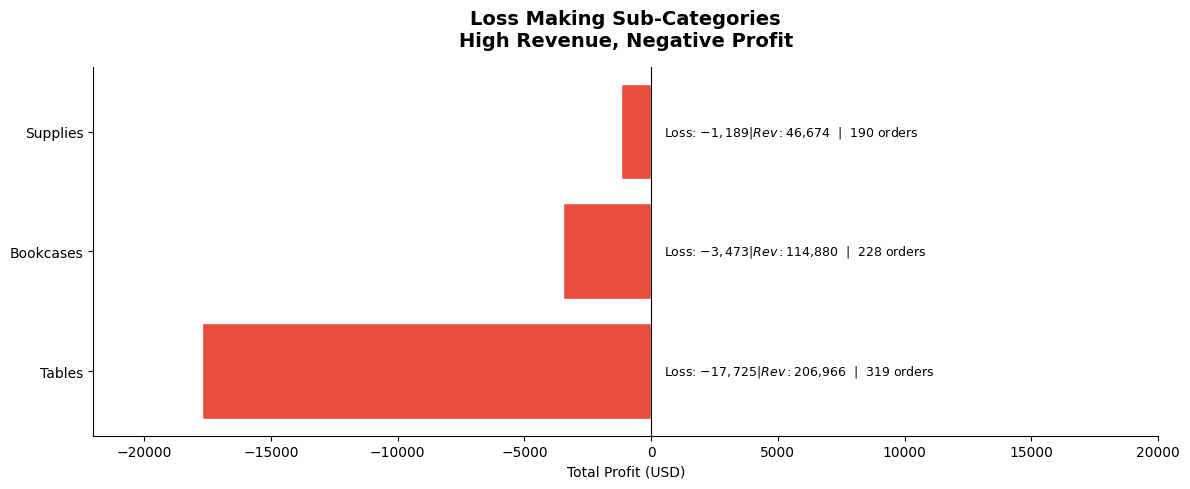

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

colors_loss = ['#e74c3c' for _ in loss_makers['Total_Profit']]

bars = ax.barh(loss_makers['Sub-Category'],
               loss_makers['Total_Profit'],
               color=colors_loss,
               edgecolor='white')

for bar, (_, row) in zip(bars, loss_makers.iterrows()):
    ax.text(500,
        bar.get_y() + bar.get_height()/2,
        f"Loss: ${row['Total_Profit']:,.0f}  |  Rev: ${row['Total_Sales']:,.0f}  |  {int(row['Order_Count'])} orders",
        va='center', ha='left', fontsize=9, color='black')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Loss Making Sub-Categories\nHigh Revenue, Negative Profit',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Profit (USD)')
ax.set_xlim(-22000, 20000)  # extra room on right for labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_lossmakers.png', dpi=150)
plt.show()

**Final Findings**
1. 2015 revenue dipped -2.8%
3. Central region lowest margin 7.9%
4. Furniture margin only 2.5%
5. Discounts above 30% generate loses
6. Tables loses `$17,725` on $207k revenue.


**Question 1**

In [26]:
print(sales[sales['sales_year'] == 2015] ['Discount'].mean(). round(3))
print(sales[sales['sales_year'] == 2014] ['Discount'].mean(). round(3))

0.156
0.158


In [27]:
yearly_discount = sales.groupby('sales_year')['Discount'].mean().round(3)
print(yearly_discount)

sales_year
2014    0.158
2015    0.156
2016    0.155
2017    0.156
Name: Discount, dtype: float64


Revenue 2015 dip was not caused by discounting. 2015 has the lowest discounting.

In [28]:
yearly_avg = sales.groupby('sales_year').agg(
    Order_Count = ('Sales', 'count'),
    Avg_Order_Val = ('Sales', 'mean'),
    Total_Sales = ('Sales', 'sum')
).reset_index()

yearly_avg['Total_Sales'] = yearly_avg['Total_Sales'].round(2)
yearly_avg['Avg_Order_Val'] = yearly_avg['Avg_Order_Val'].round(2)

print(yearly_avg)

   sales_year  Order_Count  Avg_Order_Val  Total_Sales
0        2014         1993         242.97    484247.50
1        2015         2102         223.85    470532.51
2        2016         2587         235.49    609205.60
3        2017         3312         221.38    733215.26


*Revenue on 2015 declined despite 109 more orders because avg order value dropped $19.12. Customers ordered more frequently but spent less per order. This suggest shift toward lower value products or smaller quantity orders in 2015.*

**Question 2**

In [29]:
central_sub = sales[sales['Region'] == 'Central'].groupby('Sub-Category')['Profit'].sum().sort_values()
print(central_sub.head(5))

Sub-Category
Furnishings   -3906.2168
Tables        -3559.6504
Appliances    -2638.6175
Bookcases     -1997.9043
Machines      -1486.0666
Name: Profit, dtype: float64


/tmp/ipykernel_16/3308114539.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  central_sub = sales[sales['Region'] == 'Central'].groupby('Sub-Category')['Profit'].sum().sort_values()


Central region's low 7.9% profit margin is driven by losses on Furnishing (Profitable but loses money here), Tables, Appliances (Profitable but loses money here), Bookcases and Machines (Profitable but loses money here). Issue in pricing, cost, discount problems?

In [30]:
region_discount = sales.groupby('Region')['Discount'].mean().round(3)
print(region_discount)

Region
Central    0.240
East       0.145
South      0.147
West       0.109
Name: Discount, dtype: float64


/tmp/ipykernel_16/1682538006.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_discount = sales.groupby('Region')['Discount'].mean().round(3)


*Central has the highest discount on Region level.*

**Question 3**

In [31]:
cat_discount = sales.groupby('Category')['Discount'].mean().round(3)
print(cat_discount)

Category
Furniture          0.174
Office Supplies    0.157
Technology         0.132
Name: Discount, dtype: float64


/tmp/ipykernel_16/1139686103.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_discount = sales.groupby('Category')['Discount'].mean().round(3)


***Yes, furniture is over discounted. Combined with high fixed costs, this explains why Furniture's profit margin collapsed to just 2.5% despite generating 32.3% of total revenue.***

Checking cost for all category and sub-category.

In [32]:
sales['Cost'] = sales['Sales'] - sales['Profit']
cost_analysis = sales.groupby('Category').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Cost = ('Cost', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

cost_analysis['Total_Sales'] = cost_analysis['Total_Sales'].round(2)
cost_analysis['Total_Cost'] = cost_analysis['Total_Cost'].round(2)
cost_analysis['Total_Profit'] = cost_analysis['Total_Profit'].round(2)
cost_analysis['Cost %'] = (cost_analysis['Total_Cost']/cost_analysis['Total_Sales'] * 100).round(2)
cost_analysis = cost_analysis.sort_values('Cost %', ascending=False).reset_index(drop=True)
print("CATEGORY COST ANALYSIS")
print(cost_analysis)

sales['Cost'] = sales['Sales'] - sales['Profit']
costsub_analysis = sales.groupby('Sub-Category').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Cost = ('Cost', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

costsub_analysis['Total_Sales'] = costsub_analysis['Total_Sales'].round(2)
costsub_analysis['Total_Cost'] = costsub_analysis['Total_Cost'].round(2)
costsub_analysis['Total_Profit'] = costsub_analysis['Total_Profit'].round(2)
costsub_analysis['Cost %'] = (costsub_analysis['Total_Cost']/costsub_analysis['Total_Sales'] * 100).round(2)
costsub_analysis = costsub_analysis.sort_values('Cost %', ascending=False).reset_index(drop=True)
print("SUB-CATEGORY COST ANALYSIS")
print(costsub_analysis)


CATEGORY COST ANALYSIS
          Category  Total_Sales  Total_Cost  Total_Profit  Cost %
0        Furniture    741999.80   723548.52      18451.27   97.51
1  Office Supplies    719047.03   596556.23     122490.80   82.96
2       Technology    836154.03   690699.08     145454.95   82.60
SUB-CATEGORY COST ANALYSIS
   Sub-Category  Total_Sales  Total_Cost  Total_Profit  Cost %
0        Tables    206965.53   224691.01     -17725.48  108.56
1     Bookcases    114880.00   118352.55      -3472.56  103.02
2      Supplies     46673.54    47862.64      -1189.10  102.55
3      Machines    189238.63   185853.87       3384.76   98.21
4        Chairs    328449.10   301858.94      26590.17   91.90
5       Storage    223843.61   202564.78      21278.83   90.49
6        Phones    330007.05   285491.32      44515.73   86.51
7   Furnishings     91705.16    78646.02      13059.14   85.76
8       Binders    203412.73   173190.97      30221.76   85.14
9    Appliances    107532.16    89394.16      18138.01  

/tmp/ipykernel_16/2917153570.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_analysis = sales.groupby('Category').agg(
/tmp/ipykernel_16/2917153570.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  costsub_analysis = sales.groupby('Sub-Category').agg(


In [33]:
cost_analysis

,Category,Total_Sales,Total_Cost,Total_Profit,Cost %
0,Furniture,741999.80,723548.52,18451.27,97.51
1,Office Supplies,719047.03,596556.23,122490.80,82.96
2,Technology,836154.03,690699.08,145454.95,82.60


In [34]:
costsub_analysis

,Sub-Category,Total_Sales,Total_Cost,Total_Profit,Cost %
0,Tables,206965.53,224691.01,-17725.48,108.56
1,Bookcases,114880.00,118352.55,-3472.56,103.02
2,Supplies,46673.54,47862.64,-1189.10,102.55
3,Machines,189238.63,185853.87,3384.76,98.21
4,Chairs,328449.10,301858.94,26590.17,91.90
5,Storage,223843.61,202564.78,21278.83,90.49
6,Phones,330007.05,285491.32,44515.73,86.51
7,Furnishings,91705.16,78646.02,13059.14,85.76
8,Binders,203412.73,173190.97,30221.76,85.14
9,Appliances,107532.16,89394.16,18138.01,83.13


* Furniture has the highest Cost % among other category.
* Table has the highest cost ratio at 108.6%, making it a loss regardless of discount, followed by Bookcase 103% and Supplies 102.6%
* Product that between 90%-100% cost % should be monitored.
* Labels have the healthiest cost with 55.6%.
* ****Recommendation : REVISE PRICING FOR THREE SUB-CATEGORIES (Table,Bookcase,Supplies) and FURNITURE CATEGORY. STOP applying discounts on Furniture category****

**Question 4**

In [35]:
high_discount = sales[sales['Discount'] >=0.3]
high_discount_region = high_discount.groupby('Region').agg(
    Order_Count = ('Sales', 'count'),
    Total_Loss = ('Profit', 'sum')
).reset_index()
high_discount_region['Total_Loss'] = high_discount_region['Total_Loss'].round(2)
print(high_discount_region)

    Region  Order_Count  Total_Loss
0  Central          643   -52392.27
1     East          461   -42088.61
2    South          171   -24880.48
3     West          118   -16014.69


/tmp/ipykernel_16/370899243.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_discount_region = high_discount.groupby('Region').agg(


***Yes, Central uses discounts 30% and above the highest of all region.***

**Question 5**

In [36]:
tables_region = sales[sales['Sub-Category'] == 'Tables'].groupby('Region').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Order_Count = ('Sales', 'count')
).reset_index()
tables_region['Total_Sales'] = tables_region['Total_Sales'].round(2)
tables_region['Total_Profit'] = tables_region['Total_Profit'].round(2)
tables_region['Profit_Margin'] = (tables_region['Total_Profit']/tables_region['Total_Sales'] * 100).round(2)
tables_region

/tmp/ipykernel_16/3250890438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tables_region = sales[sales['Sub-Category'] == 'Tables'].groupby('Region').agg(


,Region,Total_Sales,Total_Profit,Order_Count,Profit_Margin
0,Central,39154.97,-3559.65,72,-9.09
1,East,39139.81,-11025.38,80,-28.17
2,South,43916.19,-4623.06,51,-10.53
3,West,84754.56,1482.61,116,1.75


**Tables loses money in 3 regions except West with East leading with -28.2% profit margin. West has the highest order count for table with 116 while south sold the least.**

Check for East Tables pricing and discount practices.

In [37]:
east_sales = sales[sales['Region'] == 'East'].groupby('Category').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Cost = ('Cost', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

east_sales['Total_Sales'] = east_sales['Total_Sales'].round(2)
east_sales['Total_Cost'] = east_sales['Total_Cost'].round(2)
east_sales['Total_Profit'] = east_sales['Total_Profit'].round(2)
east_sales['Cost %'] = (east_sales['Total_Cost']/east_sales['Total_Sales'] * 100).round(2)
east_sales = east_sales.sort_values('Cost %', ascending=False).reset_index(drop=True)
print("EAST SALES ANALYSIS")
print(east_sales)

sales['Cost'] = sales['Sales'] - sales['Profit']
eastsub_sales = sales[sales['Region'] == 'East'].groupby('Sub-Category').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Cost = ('Cost', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

eastsub_sales['Total_Sales'] = eastsub_sales['Total_Sales'].round(2)
eastsub_sales['Total_Cost'] = eastsub_sales['Total_Cost'].round(2)
eastsub_sales['Total_Profit'] = eastsub_sales['Total_Profit'].round(2)
eastsub_sales['Cost %'] = (eastsub_sales['Total_Cost']/eastsub_sales['Total_Sales'] * 100).round(2)
eastsub_sales = eastsub_sales.sort_values('Cost %', ascending=False).reset_index(drop=True)
print("SUB-CATEGORY COST ANALYSIS")
print(eastsub_sales)

EAST SALES ANALYSIS
          Category  Total_Sales  Total_Cost  Total_Profit  Cost %
0        Furniture    208291.20   205245.04       3046.17   98.54
1       Technology    264973.98   217511.95      47462.04   82.09
2  Office Supplies    205516.06   164501.48      41014.58   80.04
SUB-CATEGORY COST ANALYSIS
   Sub-Category  Total_Sales  Total_Cost  Total_Profit  Cost %
0        Tables     39139.81    50165.19     -11025.38  128.17
1      Supplies     10760.12    11915.25      -1155.14  110.74
2     Bookcases     43819.33    44986.97      -1167.63  102.66
3        Chairs     96260.68    86902.91       9357.77   90.28
4      Machines     66106.17    59177.52       6928.64   89.52
5       Storage     71612.58    63223.21       8389.37   88.29
6        Phones    100614.98    88300.30      12314.69   87.76
7   Furnishings     29071.38    23189.97       5881.41   79.77
8       Binders     53498.00    42230.06      11267.93   78.94
9    Appliances     34188.47    25797.05       8391.41   75

/tmp/ipykernel_16/1862309948.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  east_sales = sales[sales['Region'] == 'East'].groupby('Category').agg(
/tmp/ipykernel_16/1862309948.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eastsub_sales = sales[sales['Region'] == 'East'].groupby('Sub-Category').agg(


***Finding***

* East spends $ 1.28 for every `$1` of Tables revenue.
* Company-wide Table cost ratio is 108.6% while East is 128.2%
* Need to check discount analysis for East

In [38]:
east_tables = sales [(sales['Region'] == 'East') & (sales['Sub-Category'] == 'Tables')]
print(f"East Tables avg discount: {east_tables['Discount'].mean().round(3)}")
print(f"East Tables discount distribution:")
print(east_tables['Discount'].value_counts().sort_index())

East Tables avg discount: 0.374
East Tables discount distribution:
Discount
0.3    21
0.4    59
Name: count, dtype: int64


In [39]:
# Overall company average discount
print(f"Company-wide avg discount: {sales['Discount'].mean().round(3)}")

# By region for comparison
print("\nAverage discount by region:")
print(sales.groupby('Region')['Discount'].mean().round(3))

# Tables specifically
print("\nAverage discount for Tables company-wide:")
print(sales[sales['Sub-Category'] == 'Tables']['Discount'].mean().round(3))

Company-wide avg discount: 0.156

Average discount by region:
Region
Central    0.240
East       0.145
South      0.147
West       0.109
Name: Discount, dtype: float64

Average discount for Tables company-wide:
0.261


/tmp/ipykernel_16/584825078.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sales.groupby('Region')['Discount'].mean().round(3))


In [40]:
# Discount by sub-category — how does Tables compare?
subcat_discount = sales.groupby('Sub-Category')['Discount'].mean().round(3)
subcat_discount = subcat_discount.sort_values(ascending=False)
print(subcat_discount)

Sub-Category
Binders        0.372
Machines       0.306
Tables         0.261
Bookcases      0.211
Chairs         0.170
Appliances     0.167
Copiers        0.162
Phones         0.155
Furnishings    0.138
Fasteners      0.082
Envelopes      0.080
Accessories    0.078
Supplies       0.077
Art            0.075
Paper          0.075
Storage        0.075
Labels         0.069
Name: Discount, dtype: float64


/tmp/ipykernel_16/3368665477.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subcat_discount = sales.groupby('Sub-Category')['Discount'].mean().round(3)


In [41]:
# Check Binders cost ratio
print(sales[sales['Sub-Category'] == 'Binders']['Profit'].sum().round(2))
print(costsub_analysis[costsub_analysis['Sub-Category'] == 'Binders'])

30221.76
  Sub-Category  Total_Sales  Total_Cost  Total_Profit  Cost %
8      Binders    203412.73   173190.97      30221.76   85.14


**Findings**
1. Company-wide avg discount is 15.6%
2. Tables company-wide avg discount is 26.1%
3. East region avg discount is 14.5%
4. East Tables avg discount is 37.4%
5. East did not over discount generally except Tables.
6. Binders is the highest discounted sub-category but still generate profit due to high cost % and Tables is the third highest.

## Executive Summary

Analysis of 9,994 Superstore orders from 2014 to 2017 reveals strong revenue growth of 51.4% masking four underlaying profitability concerns.

### Revenue Quality is Declining
Despite record revenue in 2017, average order value has fallen consistently from $242.97 in 2014 to $221.38 in 2017. Growth is driven by volume not value.

### Central Region is Underperforming
Central's 7.9% profit margin, the lowest of all region is directly linked to its 24.0% average discount rate, doubled West's 10.9%.

### Furniture Has a Structural Cost Problem
Furniture generates 32.3% of revenue but only 2.5% margin. At 97.5% cost ratio, three sub-categories; Tables, Bookcases and Supplies sells below cost before any discount is applied.

### Discounting Above 30% Destroys Profit
1,393 orders above 30% discount lost `$135,375`. Products above 95% cost ratio cannot absorb any discounting. East Tables at `128.2%` cost ratio and 37.4% discount lost $11,025 alone.

### Recommendations

| Priority | Action |
|---|---|
|1|Hard cap discounts at 20% company-wide|
|2|Zero discounts on products above 95% cost ratio|
|3|Immediate pricing revision for Furniture|
|4|Evaluate Tables and Bookcases for discontinuation|